In [1]:
%load_ext autoreload
%autoreload 2

Data Loader

In [2]:
import data_loader

output_root = "../../artifacts"
path = "../../data/merged_na_mwh_df.csv"
sales_translated_in_energy = "quarterly_MWh"
independent_variables = ["interest_rates", "gdp_income", "employment", "price_indices", "exchange_rates", "liquidity_and_reserves", "auto_loans"]

In [3]:
data_loader.remove_artifact_folder()
data, features, scaled_data, scaler, q_agg_data = data_loader.run_process(path, 
                                                                          sales_translated_in_energy, 
                                                                          independent_variables,
                                                                          save_as_csv=True)

Corr

In [4]:
import correlation

In [5]:
df = q_agg_data.dropna()
target_variable = sales_translated_in_energy
threshold = 0.85
top_n = 2

[1/2] 피어슨 상관분석 수행...
  - 임계값 이상 변수 수: 22
[2/3] 교차 상관관계 분석 수행...
  - 교차 상관관계 분석 완료: 9개 변수
[3/3] 상관계수 시각화...
그래프가 ../../artifacts/corr_test.png에 저장되었습니다.


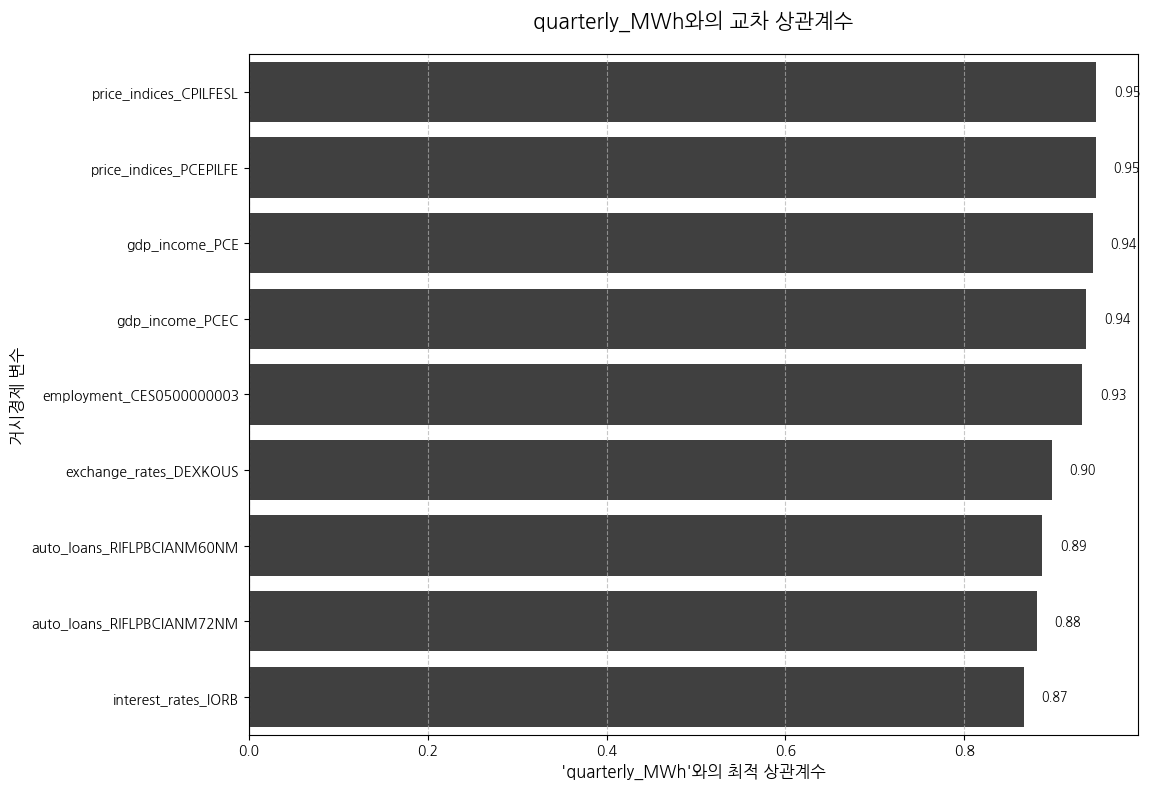

상관분석 결과가 ../../artifacts/corr_test_results.json에 저장되었습니다.

[완료] 상관분석 및 시각화가 종료되었습니다.
Significant Variables: ['quarterly_MWh', 'price_indices_CPILFESL', 'price_indices_PCEPILFE', 'gdp_income_PCE', 'price_indices_CPIFABSL', 'price_indices_PCEPI', 'price_indices_CPIAUCSL', 'gdp_income_PCEC', 'gdp_income_GDP', 'employment_CES0500000003', 'gdp_income_GDPDEF', 'gdp_income_GDPPOT', 'gdp_income_DPI', 'gdp_income_GDPC1', 'exchange_rates_DEXKOUS', 'price_indices_WPSFD49207', 'gdp_income_A939RX0Q048SBEA', 'auto_loans_RIFLPBCIANM60NM', 'auto_loans_RIFLPBCIANM72NM', 'gdp_income_W875RX1', 'gdp_income_TOTALSL', 'auto_loans_TERMCBAUTO48NS', 'interest_rates_IORB']
Correlation Series: {'quarterly_MWh': 1.0, 'price_indices_CPILFESL': 0.947018896146229, 'price_indices_PCEPILFE': 0.9468060290358047, 'gdp_income_PCE': 0.9435478987684763, 'price_indices_CPIFABSL': 0.942385823579694, 'price_indices_PCEPI': 0.9412945698235724, 'price_indices_CPIAUCSL': 0.9398814000653644, 'gdp_income_PCEC': 0.936031804720233, 

In [6]:
sig_vars, corr_series, cross_corr_dict = correlation.run_process(
    df,
    target_variable=target_variable,
    independent_variable_prefixes=independent_variables,
    corr_threshold=threshold,
    visualize=True,
    output_path=f"{output_root}/corr_test.png"
)

print(f"Significant Variables: {sig_vars}")
print(f"Correlation Series: {corr_series}")

In [7]:
sig_vars

['quarterly_MWh',
 'price_indices_CPILFESL',
 'price_indices_PCEPILFE',
 'gdp_income_PCE',
 'price_indices_CPIFABSL',
 'price_indices_PCEPI',
 'price_indices_CPIAUCSL',
 'gdp_income_PCEC',
 'gdp_income_GDP',
 'employment_CES0500000003',
 'gdp_income_GDPDEF',
 'gdp_income_GDPPOT',
 'gdp_income_DPI',
 'gdp_income_GDPC1',
 'exchange_rates_DEXKOUS',
 'price_indices_WPSFD49207',
 'gdp_income_A939RX0Q048SBEA',
 'auto_loans_RIFLPBCIANM60NM',
 'auto_loans_RIFLPBCIANM72NM',
 'gdp_income_W875RX1',
 'gdp_income_TOTALSL',
 'auto_loans_TERMCBAUTO48NS',
 'interest_rates_IORB']

Random Forest

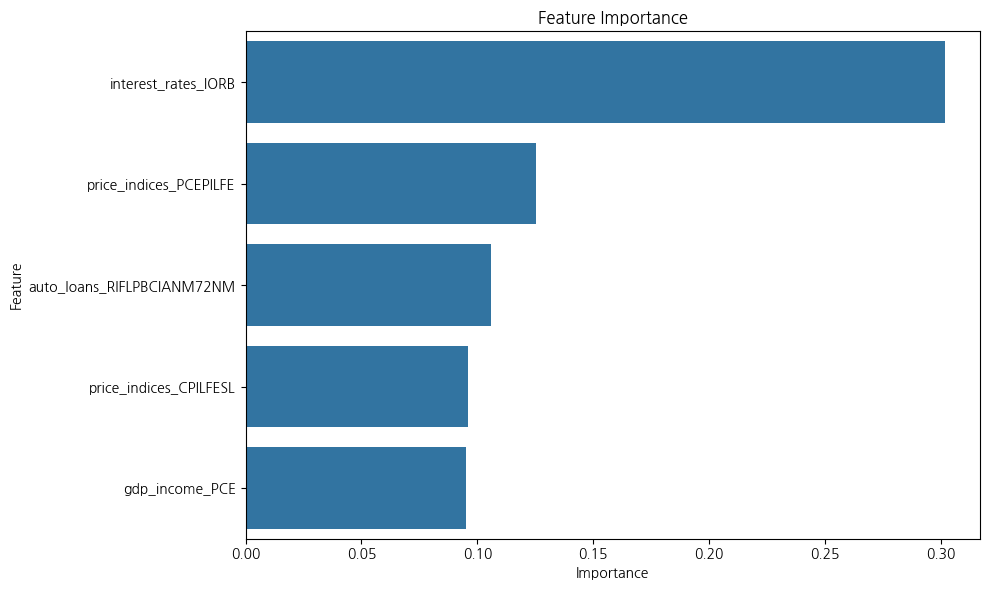

특성 중요도 그래프가 ../../artifacts/rf_test_1.png에 저장되었습니다.
그래프가 ../../artifacts/rf_test_2.png에 저장되었습니다.


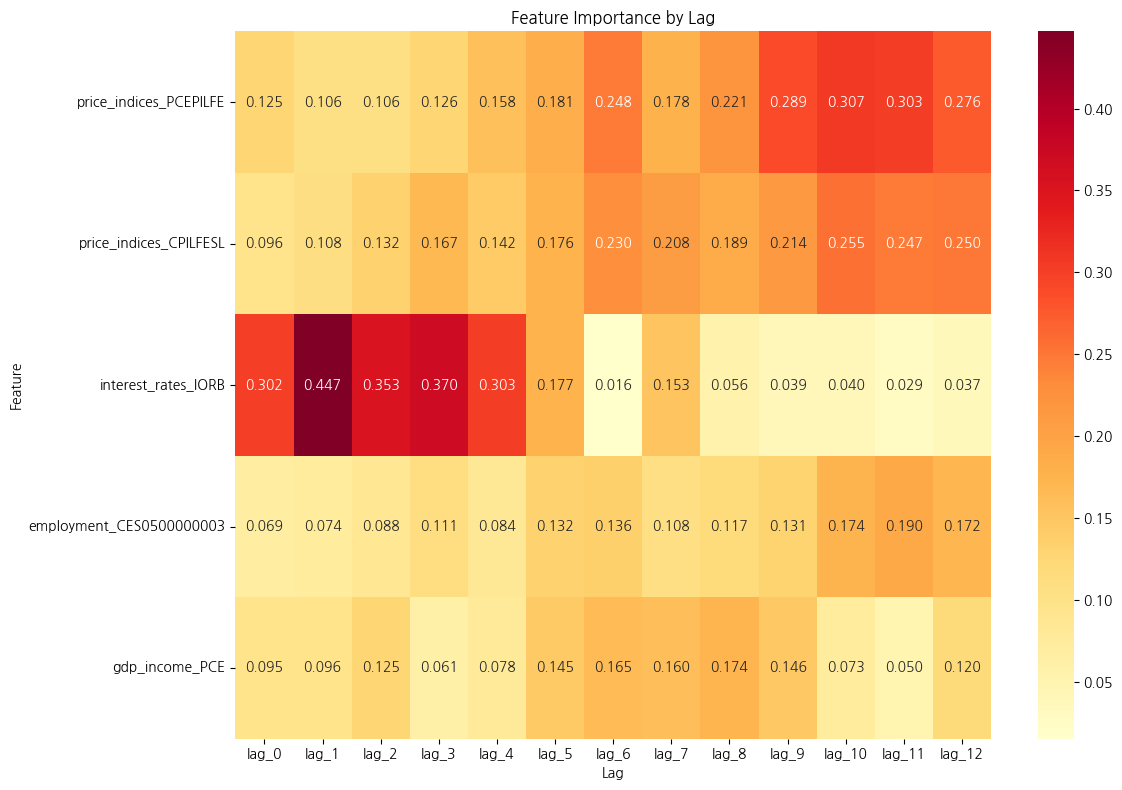

랜덤 포레스트 분석 결과가 ../../artifacts/rf_test_results.json에 저장되었습니다.


In [8]:
import rf_model

importance_df, lag_results = rf_model.run_process(df, 
                                                  target_variable, 
                                                  cross_corr_dict, 
                                                  output_path=f"{output_root}/rf_test.png")

In [9]:
importance_df

,feature,importance
8,interest_rates_IORB,0.301779
1,price_indices_PCEPILFE,0.125401
7,auto_loans_RIFLPBCIANM72NM,0.105944
0,price_indices_CPILFESL,0.095836
2,gdp_income_PCE,0.095321


In [10]:
lag_results

{0:                             feature  importance            original_feature
 8         interest_rates_IORB_lag_0    0.301779         interest_rates_IORB
 1      price_indices_PCEPILFE_lag_0    0.125401      price_indices_PCEPILFE
 7  auto_loans_RIFLPBCIANM72NM_lag_0    0.105944  auto_loans_RIFLPBCIANM72NM
 0      price_indices_CPILFESL_lag_0    0.095836      price_indices_CPILFESL
 2              gdp_income_PCE_lag_0    0.095321              gdp_income_PCE
 5      exchange_rates_DEXKOUS_lag_0    0.074003      exchange_rates_DEXKOUS
 3             gdp_income_PCEC_lag_0    0.073988             gdp_income_PCEC
 4    employment_CES0500000003_lag_0    0.068510    employment_CES0500000003
 6  auto_loans_RIFLPBCIANM60NM_lag_0    0.059219  auto_loans_RIFLPBCIANM60NM,
 1:                             feature  importance            original_feature
 8         interest_rates_IORB_lag_1    0.447088         interest_rates_IORB
 0      price_indices_CPILFESL_lag_1    0.108407      price_indices_C

Granger

In [11]:
import granger

In [12]:
filtered_granger_dict = granger.run_process(
    df, 
    target_variable=target_variable,
    independent_variable_prefixes=independent_variables,
    cross_corr_threshold=0.2,
    num_top_corr_vars=5,
    max_lag_cross_corr=60,
    max_lag_granger=12,
    granger_significance_level=0.05,
    apply_diff_to_granger=True,
    diff_periods_granger=1,
    visualize=True,
    output_path=f"{output_root}/granger_test.png"
)

[1/4] 그레인저 인과성 분석 수행...


/home/yunchae/anaconda3/envs/bedrock_manus/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/yunchae/anaconda3/envs/bedrock_manus/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/yunchae/anaconda3/envs/bedrock_manus/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/yunchae/anaconda3/envs/bedrock_manus/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/yunchae/anaconda3/envs/bedrock_manus/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/yunchae/anaconda3/envs/bedrock_ma

  - 분석된 변수 수: 5
[2/4] 유의미한 인과성 결과 필터링...
  - 유의미한 인과성 변수 수: 4
[3/4] 인과성 분석 결과 시각화...

=== 그레인저 인과성 분석 결과 요약 ===
총 분석 변수 수: 4

상위 5개 변수의 결과:
               Variable  P-value  F-statistic  Lag
interest_rates_FEDFUNDS 0.000723    15.354202   11
    interest_rates_SOFR 0.002372    10.553599   11
    interest_rates_EFFR 0.014007     5.810788   11
     interest_rates_DFF 0.014770     5.702354   11
그래프가 ../../artifacts/granger_test_1.png에 저장되었습니다.
[4/4] 인과성 네트워크 시각화...
그래프가 ../../artifacts/granger_test_2.png에 저장되었습니다.
그레인저 분석 결과가 ../../artifacts/granger_test_results.json에 저장되었습니다.

[완료] 그레인저 인과성 분석 및 시각화가 종료되었습니다.


<Figure size 640x480 with 0 Axes>

In [13]:
filtered_granger_dict 

{'interest_rates_SOFR': {'granger_causality_to_target': {'differencing_applied': True,
   'diff_periods': 1,
   'max_lag_tested': 12,
   'significant_at_alpha': 0.05,
   'is_causal_overall': True,
   'best_lag': {'lag': 11,
    'F_statistic': np.float64(10.553598911265995),
    'p_value': np.float64(0.00237169438878925),
    'is_causal': np.True_}}},
 'interest_rates_EFFR': {'granger_causality_to_target': {'differencing_applied': True,
   'diff_periods': 1,
   'max_lag_tested': 12,
   'significant_at_alpha': 0.05,
   'is_causal_overall': True,
   'best_lag': {'lag': 11,
    'F_statistic': np.float64(5.810788293217362),
    'p_value': np.float64(0.014006850967239741),
    'is_causal': np.True_}}},
 'interest_rates_FEDFUNDS': {'granger_causality_to_target': {'differencing_applied': True,
   'diff_periods': 1,
   'max_lag_tested': 12,
   'significant_at_alpha': 0.05,
   'is_causal_overall': True,
   'best_lag': {'lag': 11,
    'F_statistic': np.float64(15.354202390770457),
    'p_value': 